# Toy 1D Regression: SVD Optimizer Analysis (full-scan)

Same scan as `toy_1d_analysis.ipynb`, but each curve is the mean across all available model seeds with a $\pm 1\sigma$ shaded band. The best hyperparameter setting per optimizer is the one minimizing mean final validation loss; LBFGS settings with NaNs anywhere in any seed's trajectory or with missing seeds are dropped before selection.

## 1. Setup & Data Loading

In [ ]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from style import set_style, lr_labels
set_style()

PLOT_DIR = Path('plots/toy_1d_fullscan')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {PLOT_DIR.resolve()}")

In [ ]:
# Load JSONL results
from style import load_results, load_results_jsonl

df = load_results("toy_1d_scan")
print(f"Total: {len(df)} experiment runs")
print(f"Optimizers: {sorted(df['optimizer'].unique())}")
print(f"Batch sizes: {sorted(df['batch_size'].unique())}")
print(f"Columns: {df.columns.tolist()}")

def is_bad(row):
    if np.isnan(row['losses']['val'][-1]):
        return True
    return False
df['is_bad'] = df.apply(is_bad, axis=1)
df = df[~df['is_bad']]
print(f"After removing bad runs: {len(df)} experiment runs")

In [ ]:
for opt in df.optimizer.unique():
    for seed in df.model_seed.unique():
        N = len(df[(df.model_seed == seed) & (df.optimizer == opt)])
        print(f"Seed {seed}: {N} {opt} runs")

In [ ]:
BASELINE_OPT = ['SGD','PolyakSGD','RMSprop','Adam','LBFGS','JD_UPGrad','HIG']
# Note: no df = df[df.model_seed == SEED_SEL] -- we keep all seeds.
HYPERPARAM_COLS_SVD = ['lr', 'k', 'rtol', 'batch_size']

In [ ]:
# Helper functions
HYPERPARAM_COLS = {
    'SGD': ['lr'],
    'Adam': ['lr'],
    'RMSprop': ['lr'],
    'LBFGS': ['lr', 'lbfgs_max_iter', 'lbfgs_history_size', 'lbfgs_line_search_fn'],
    'PolyakSGD': ['polyak_max_lr', 'polyak_f_star', 'polyak_eps'],
    'HIG': ['lr', 'tau'],
    'JD_UPGrad': ['lr'],
}

def get_final_loss(row, loss_type='val'):
    losses = row['losses'][loss_type]
    for v in reversed(losses):
        if v is not None and not (isinstance(v, float) and np.isnan(v)):
            return v
    return np.nan

def get_loss_curve(row, loss_type='val'):
    return np.array(row['losses'][loss_type])

def has_nan_trajectory(row):
    for key in ('train', 'val'):
        arr = row['losses'].get(key, [])
        for v in arr:
            if v is None or (isinstance(v, float) and np.isnan(v)):
                return True
    return False

def aggregate_curves(group_df, key, prepend=None):
    """Mean and std across rows of group_df for losses[key]; truncated to
    shortest trajectory. If prepend is not None, prepends that scalar to each
    curve before stacking (used to align wall-time arrays with epoch 0)."""
    curves = []
    for _, r in group_df.iterrows():
        c = np.array(r['losses'][key], dtype=float)
        if prepend is not None:
            c = np.concatenate([np.array([prepend], dtype=float), c])
        curves.append(c)
    n = min(len(c) for c in curves)
    arr = np.stack([c[:n] for c in curves])
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)

def aggregate_cumulative_time(group_df, prepend=None):
    """Mean cumulative wall-time across seeds (cumsum of mean epoch_times)."""
    mean_et, _ = aggregate_curves(group_df, 'epoch_times', prepend=prepend)
    return np.cumsum(mean_et)

def select_best_group(df_sub, hyperparam_cols, optimizer=None, n_seeds=None):
    """Pick the hyperparameter setting with the lowest mean final_val_loss.

    For LBFGS, drop any setting where (a) any seed has a NaN anywhere in its
    train/val trajectory, or (b) the setting is missing seeds (count <
    n_seeds). Returns the sub-df of all seed rows for the chosen setting and
    a dict of the chosen hyperparameters."""
    cols = list(hyperparam_cols)
    df_local = df_sub.copy()
    if optimizer == 'LBFGS':
        if n_seeds is None:
            n_seeds = df_local['model_seed'].nunique()
        df_local['_has_nan'] = df_local.apply(has_nan_trajectory, axis=1)
        bad_keys = set()
        for key, g in df_local.groupby(cols, dropna=False):
            k = key if isinstance(key, tuple) else (key,)
            if g['_has_nan'].any() or g['model_seed'].nunique() < n_seeds:
                bad_keys.add(k)
        means = df_local.groupby(cols, dropna=False)['final_val_loss'].mean()
        candidates = {}
        for k, v in means.items():
            tk = k if isinstance(k, tuple) else (k,)
            if tk not in bad_keys and not np.isnan(v):
                candidates[tk] = v
        if not candidates:
            raise ValueError("No LBFGS settings remain after NaN/missing-seed filtering.")
        best_key = min(candidates, key=candidates.get)
    else:
        means = df_local.groupby(cols, dropna=False)['final_val_loss'].mean()
        bk = means.idxmin()
        best_key = bk if isinstance(bk, tuple) else (bk,)
    mask = pd.Series(True, index=df_sub.index)
    for c, v in zip(cols, best_key):
        if pd.isna(v):
            mask &= df_sub[c].isna()
        else:
            mask &= df_sub[c] == v
    return df_sub[mask], dict(zip(cols, best_key))

# Add derived columns
df['final_val_loss'] = df.apply(lambda r: get_final_loss(r, 'val'), axis=1)
df['final_train_loss'] = df.apply(lambda r: get_final_loss(r, 'train'), axis=1)
df['total_time'] = df['losses'].apply(lambda l: l.get('total_time', np.nan))
df['avg_epoch_time'] = df['losses'].apply(lambda l: l.get('avg_epoch_time', np.nan))
df['avg_batch_time_train'] = df['losses'].apply(lambda l: l.get('avg_batch_time_train', np.nan))

df_svd = df[(df['optimizer'] == 'SVD')].copy()
df_baseline = df[df['optimizer'] != 'SVD'].copy()

n_seeds = df['model_seed'].nunique()
print(f"Using {n_seeds} model seeds: {sorted(df['model_seed'].unique())}")

bs = df.batch_size.unique()[0]
baseline_optimizers = sorted(df_baseline['optimizer'].unique().tolist())
ks = sorted(df_svd['k'].dropna().unique())
svd_lrs = sorted(df_svd['lr'].unique())
svd_rtols = sorted(df_svd['rtol'].dropna().unique())

print(f"\nSVD: {len(df_svd)} runs")
print(f"  ks: {ks}")
print(f"  lrs: {svd_lrs}")
print(f"  rtols: {svd_rtols}")
print(f"\nBaseline: {len(df_baseline)} runs")
print(f"  Optimizers: {baseline_optimizers}")
print(f"  lrs: {sorted([L for L in df_baseline['lr'].unique() if L is not None])}")

# Custom plots

### Best of each optimizer (mean over seeds, $\pm 1\sigma$ band)

In [ ]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))

# Best SVD
best_svd_df, svd_params = select_best_group(
    df_svd[df_svd['batch_size'] == bs], HYPERPARAM_COLS_SVD, optimizer='SVD'
)
mean, std = aggregate_curves(best_svd_df, 'train')
n_epochs = len(mean)
epochs_train = np.arange(1, n_epochs + 1)
svd_label = (f"Sven ($\eta={svd_params['lr']}$, "
             f"$k={int(svd_params['k'])}$, rtol=${lr_labels[svd_params['rtol']]}$)")
ax.plot(epochs_train, mean, color='k', linewidth=3, label=svd_label, zorder=2)
ax.fill_between(epochs_train, mean - std, mean + std, color='k', alpha=0.2, zorder=2)

# Best baselines
for i, opt in enumerate(BASELINE_OPT):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_df, _ = select_best_group(opt_df, HYPERPARAM_COLS[opt], optimizer=opt, n_seeds=n_seeds)
    mean, std = aggregate_curves(best_df, 'train')
    e = np.arange(1, len(mean) + 1)
    ax.plot(e, mean, color=colors[i], linewidth=2, label=opt, zorder=1)
    ax.fill_between(e, mean - std, mean + std, color=colors[i], alpha=0.2, zorder=1)

ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss')
ax.set_yscale('log')
plt.legend(ncol=2, loc='upper right', frameon=True, framealpha=1)
ax.set_title(f"1D Regression ($B = {bs}$)")
plt.ylim([None, 20])
plt.xlim(0, n_epochs + 1)
plt.xticks(np.arange(0, n_epochs + 1, max(1, n_epochs // 10)))
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'train_loss_best.pdf')
plt.show()

In [ ]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))

# Best SVD
best_svd_df, svd_params = select_best_group(
    df_svd[df_svd['batch_size'] == bs], HYPERPARAM_COLS_SVD, optimizer='SVD'
)
mean, std = aggregate_curves(best_svd_df, 'val')
n_epochs = len(mean)
epochs_val = np.arange(0, n_epochs)
svd_label = (f"Sven ($\eta={svd_params['lr']}$, "
             f"$k={int(svd_params['k'])}$, rtol=${lr_labels[svd_params['rtol']]}$)")
ax.plot(epochs_val, mean, color='k', linewidth=3, label=svd_label, zorder=2)
ax.fill_between(epochs_val, mean - std, mean + std, color='k', alpha=0.2, zorder=2)

# Best baselines
for i, opt in enumerate(BASELINE_OPT):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_df, _ = select_best_group(opt_df, HYPERPARAM_COLS[opt], optimizer=opt, n_seeds=n_seeds)
    mean, std = aggregate_curves(best_df, 'val')
    e = np.arange(0, len(mean))
    ax.plot(e, mean, color=colors[i], linewidth=2, label=opt, zorder=1)
    ax.fill_between(e, mean - std, mean + std, color=colors[i], alpha=0.2, zorder=1)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
plt.legend(ncol=2, loc='upper right', frameon=True, framealpha=1)
ax.set_title(f"1D Regression ($B = {bs}$)")
plt.ylim([None, 5])
plt.xlim(0, n_epochs)
plt.xticks(np.arange(0, n_epochs + 1, max(1, n_epochs // 10)))
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'val_loss_best.pdf')
plt.show()

### Wall-time vs loss

In [ ]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))

# Best SVD
best_svd_df, svd_params = select_best_group(
    df_svd[df_svd['batch_size'] == bs], HYPERPARAM_COLS_SVD, optimizer='SVD'
)
mean, std = aggregate_curves(best_svd_df, 'train')
t = aggregate_cumulative_time(best_svd_df)
svd_label = (f"Sven ($\eta={svd_params['lr']}$, $k={int(svd_params['k'])}$)")
ax.plot(t, mean, color='k', linewidth=3, label=svd_label, zorder=2)
ax.fill_between(t, mean - std, mean + std, color='k', alpha=0.2, zorder=2)

# Best baselines
for i, opt in enumerate(BASELINE_OPT):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_df, _ = select_best_group(opt_df, HYPERPARAM_COLS[opt], optimizer=opt, n_seeds=n_seeds)
    mean, std = aggregate_curves(best_df, 'train')
    t = aggregate_cumulative_time(best_df)
    ax.plot(t, mean, color=colors[i], linewidth=2, label=opt, zorder=1)
    ax.fill_between(t, mean - std, mean + std, color=colors[i], alpha=0.2, zorder=1)

ax.set_xlabel('Wall Time (s)')
ax.set_ylabel('Train Loss')
ax.set_yscale('log')
plt.legend(ncol=2, loc='upper right', frameon=True, framealpha=1)
ax.set_title(f"1D Regression ($B = {bs}$)")
plt.ylim([None, 20])
plt.xscale('log')
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'wall_time_vs_train_loss_best.pdf')
plt.show()

In [ ]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))

# Best SVD
best_svd_df, svd_params = select_best_group(
    df_svd[df_svd['batch_size'] == bs], HYPERPARAM_COLS_SVD, optimizer='SVD'
)
mean, std = aggregate_curves(best_svd_df, 'val')
# Prepend 1s to align epoch 0 with t=1 (matches the original notebook).
t = aggregate_cumulative_time(best_svd_df, prepend=1)
svd_label = (f"Sven ($\eta={svd_params['lr']}$, $k={int(svd_params['k'])}$)")
ax.plot(t, mean, color='k', linewidth=3, label=svd_label, zorder=2)
ax.fill_between(t, mean - std, mean + std, color='k', alpha=0.2, zorder=2)

# Best baselines
for i, opt in enumerate(BASELINE_OPT):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_df, _ = select_best_group(opt_df, HYPERPARAM_COLS[opt], optimizer=opt, n_seeds=n_seeds)
    mean, std = aggregate_curves(best_df, 'val')
    t = aggregate_cumulative_time(best_df, prepend=1)
    ax.plot(t, mean, color=colors[i], linewidth=2, label=opt, zorder=1)
    ax.fill_between(t, mean - std, mean + std, color=colors[i], alpha=0.2, zorder=1)

ax.set_xlabel('Wall Time + 1 (sec)')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
plt.legend(ncol=2, loc='upper right', frameon=True, framealpha=1)
ax.set_title(f"1D Regression ($B = {bs}$)")
plt.ylim([None, 20])
plt.xlim([1, None])
plt.xscale('log')
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'wall_time_vs_val_loss_best.pdf')
plt.show()

### overlay different $k$ values (mean over seeds, $\pm 1\sigma$ band)

In [ ]:
for LR in [0.05, 0.1, 0.5]:
    for RTOL in [0.0001, 0.001, 0.01]:
        fig, ax = plt.subplots(figsize=(8, 6))
        df_sel = df_svd[(df_svd['batch_size'] == bs) & (df_svd['lr'] == LR) & (df_svd['rtol'] == RTOL)]
        if len(df_sel) == 0:
            plt.close(fig)
            continue
        k_values = sorted(df_sel['k'].unique())
        kcolors = sns.color_palette("viridis", n_colors=len(k_values))
        n_epochs = 0
        for i, k in enumerate(k_values):
            group = df_sel[df_sel['k'] == k]
            mean, std = aggregate_curves(group, 'train')
            n_epochs = max(n_epochs, len(mean))
            epochs = np.arange(1, len(mean) + 1)
            ax.plot(epochs, mean, label=f"$k={int(k)}$", color=kcolors[i], linewidth=3)
            ax.fill_between(epochs, mean - std, mean + std, color=kcolors[i], alpha=0.2)

        df_sgd = df_baseline[(df_baseline['batch_size'] == bs) & (df_baseline['optimizer'] == 'SGD')]
        best_sgd_df, sgd_params = select_best_group(df_sgd, HYPERPARAM_COLS['SGD'], optimizer='SGD', n_seeds=n_seeds)
        mean, std = aggregate_curves(best_sgd_df, 'train')
        epochs = np.arange(1, len(mean) + 1)
        ax.plot(epochs, mean, label=f"SGD ($\eta={lr_labels[sgd_params['lr']]}$)",
                color='k', linestyle='--', linewidth=3)
        ax.fill_between(epochs, mean - std, mean + std, color='k', alpha=0.2)

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Train Loss')
        ax.set_yscale('log')
        plt.legend(ncol=3, loc='upper center', frameon=True, framealpha=1)
        ax.set_title(f"Sven, 1D Regression ($B = {bs}$, $\eta={LR}$, rtol = ${lr_labels[RTOL]}$)")
        plt.ylim([None, 50])
        plt.xlim(0, n_epochs + 1)
        plt.xticks(np.arange(0, n_epochs + 1, max(1, n_epochs // 10)))
        plt.grid(axis='both', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f"train_loss_k_comparison_bs{bs}_lr{LR}_rtol{RTOL}.pdf")
        plt.show()

In [ ]:
for LR in [0.05, 0.1, 0.5]:
    for RTOL in [0.0001, 0.001, 0.01]:
        fig, ax = plt.subplots(figsize=(8, 6))
        df_sel = df_svd[(df_svd['batch_size'] == bs) & (df_svd['lr'] == LR) & (df_svd['rtol'] == RTOL)]
        if len(df_sel) == 0:
            plt.close(fig)
            continue
        k_values = sorted(df_sel['k'].unique())
        kcolors = sns.color_palette("viridis", n_colors=len(k_values))
        n_epochs = 0
        for i, k in enumerate(k_values):
            group = df_sel[df_sel['k'] == k]
            mean, std = aggregate_curves(group, 'val')
            n_epochs = max(n_epochs, len(mean))
            epochs = np.arange(0, len(mean))
            ax.plot(epochs, mean, label=f"$k={int(k)}$", color=kcolors[i], linewidth=3)
            ax.fill_between(epochs, mean - std, mean + std, color=kcolors[i], alpha=0.2)

        df_sgd = df_baseline[(df_baseline['batch_size'] == bs) & (df_baseline['optimizer'] == 'SGD')]
        best_sgd_df, sgd_params = select_best_group(df_sgd, HYPERPARAM_COLS['SGD'], optimizer='SGD', n_seeds=n_seeds)
        mean, std = aggregate_curves(best_sgd_df, 'val')
        epochs = np.arange(0, len(mean))
        ax.plot(epochs, mean, label=f"SGD ($\eta={lr_labels[sgd_params['lr']]}$)",
                color='k', linestyle='--', linewidth=3)
        ax.fill_between(epochs, mean - std, mean + std, color='k', alpha=0.2)

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Validation Loss')
        ax.set_yscale('log')
        plt.legend(ncol=3, loc='upper center', frameon=True, framealpha=1)
        ax.set_title(f"Sven, 1D Regression ($B = {bs}$, $\eta={LR}$, rtol = ${lr_labels[RTOL]}$)")
        plt.ylim([None, 50])
        plt.xlim(0, n_epochs + 1)
        plt.xticks(np.arange(0, n_epochs + 1, max(1, n_epochs // 10)))
        plt.grid(axis='both', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f"val_loss_k_comparison_bs{bs}_lr{LR}_rtol{RTOL}.pdf")
        plt.show()

# Same thing but randomized SVD

In [1]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from style import set_style, lr_labels
set_style()

PLOT_DIR = Path('plots/toy_1d_fullscan_SVDrand')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {PLOT_DIR.resolve()}")

Plots will be saved to: /Users/sambt/iaifi/sv3/analysis/plots/toy_1d_fullscan_SVDrand


In [7]:
# Load JSONL results
from style import load_results, load_results_jsonl

df_svd = load_results("toy_1d_scan_SVDrand")

df2 = load_results("toy_1d_scan")
df_baseline = df2[df2['optimizer'] != 'SVD'].copy()
del df2

def is_bad(row):
    if np.isnan(row['losses']['val'][-1]):
        return True
    return False
df_baseline['is_bad'] = df_baseline.apply(is_bad, axis=1)
df_baseline = df_baseline[~df_baseline['is_bad']]
print(f"After removing bad runs: {len(df_baseline)} experiment runs")

Loaded 609 runs from ../experiment_results/toy_1d_scan_SVDrand/ (directory format)
Loaded 1439 runs from ../experiment_results/toy_1d_scan/ (directory format)
After removing bad runs: 573 experiment runs


In [8]:
for opt in df_svd.optimizer.unique():
    for seed in df_svd.model_seed.unique():
        N = len(df_svd[(df_svd.model_seed == seed) & (df_svd.optimizer == opt)])
        print(f"Seed {seed}: {N} {opt} runs")

Seed 4310: 68 SVD runs
Seed 4311: 67 SVD runs
Seed 4312: 71 SVD runs
Seed 4313: 68 SVD runs
Seed 4314: 66 SVD runs
Seed 4315: 66 SVD runs
Seed 4316: 66 SVD runs
Seed 4317: 70 SVD runs
Seed 4318: 67 SVD runs


In [9]:
BASELINE_OPT = ['SGD','PolyakSGD','RMSprop','Adam','LBFGS','JD_UPGrad','HIG']
# Note: no df = df[df.model_seed == SEED_SEL] -- we keep all seeds.
HYPERPARAM_COLS_SVD = ['lr', 'k', 'rtol', 'batch_size']

In [10]:
# Helper functions
HYPERPARAM_COLS = {
    'SGD': ['lr'],
    'Adam': ['lr'],
    'RMSprop': ['lr'],
    'LBFGS': ['lr', 'lbfgs_max_iter', 'lbfgs_history_size', 'lbfgs_line_search_fn'],
    'PolyakSGD': ['polyak_max_lr', 'polyak_f_star', 'polyak_eps'],
    'HIG': ['lr', 'tau'],
    'JD_UPGrad': ['lr'],
}

def get_final_loss(row, loss_type='val'):
    losses = row['losses'][loss_type]
    for v in reversed(losses):
        if v is not None and not (isinstance(v, float) and np.isnan(v)):
            return v
    return np.nan

def get_loss_curve(row, loss_type='val'):
    return np.array(row['losses'][loss_type])

def has_nan_trajectory(row):
    for key in ('train', 'val'):
        arr = row['losses'].get(key, [])
        for v in arr:
            if v is None or (isinstance(v, float) and np.isnan(v)):
                return True
    return False

def aggregate_curves(group_df, key, prepend=None):
    """Mean and std across rows of group_df for losses[key]; truncated to
    shortest trajectory. If prepend is not None, prepends that scalar to each
    curve before stacking (used to align wall-time arrays with epoch 0)."""
    curves = []
    for _, r in group_df.iterrows():
        c = np.array(r['losses'][key], dtype=float)
        if prepend is not None:
            c = np.concatenate([np.array([prepend], dtype=float), c])
        curves.append(c)
    n = min(len(c) for c in curves)
    arr = np.stack([c[:n] for c in curves])
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)

def aggregate_cumulative_time(group_df, prepend=None):
    """Mean cumulative wall-time across seeds (cumsum of mean epoch_times)."""
    mean_et, _ = aggregate_curves(group_df, 'epoch_times', prepend=prepend)
    return np.cumsum(mean_et)

def select_best_group(df_sub, hyperparam_cols, optimizer=None, n_seeds=None):
    """Pick the hyperparameter setting with the lowest mean final_val_loss.

    For LBFGS, drop any setting where (a) any seed has a NaN anywhere in its
    train/val trajectory, or (b) the setting is missing seeds (count <
    n_seeds). Returns the sub-df of all seed rows for the chosen setting and
    a dict of the chosen hyperparameters."""
    cols = list(hyperparam_cols)
    df_local = df_sub.copy()
    if optimizer == 'LBFGS':
        if n_seeds is None:
            n_seeds = df_local['model_seed'].nunique()
        df_local['_has_nan'] = df_local.apply(has_nan_trajectory, axis=1)
        bad_keys = set()
        for key, g in df_local.groupby(cols, dropna=False):
            k = key if isinstance(key, tuple) else (key,)
            if g['_has_nan'].any() or g['model_seed'].nunique() < n_seeds:
                bad_keys.add(k)
        means = df_local.groupby(cols, dropna=False)['final_val_loss'].mean()
        candidates = {}
        for k, v in means.items():
            tk = k if isinstance(k, tuple) else (k,)
            if tk not in bad_keys and not np.isnan(v):
                candidates[tk] = v
        if not candidates:
            raise ValueError("No LBFGS settings remain after NaN/missing-seed filtering.")
        best_key = min(candidates, key=candidates.get)
    else:
        means = df_local.groupby(cols, dropna=False)['final_val_loss'].mean()
        bk = means.idxmin()
        best_key = bk if isinstance(bk, tuple) else (bk,)
    mask = pd.Series(True, index=df_sub.index)
    for c, v in zip(cols, best_key):
        if pd.isna(v):
            mask &= df_sub[c].isna()
        else:
            mask &= df_sub[c] == v
    return df_sub[mask], dict(zip(cols, best_key))

# Add derived columns
df_svd['final_val_loss'] = df_svd.apply(lambda r: get_final_loss(r, 'val'), axis=1)
df_svd['final_train_loss'] = df_svd.apply(lambda r: get_final_loss(r, 'train'), axis=1)
df_svd['total_time'] = df_svd['losses'].apply(lambda l: l.get('total_time', np.nan))
df_svd['avg_epoch_time'] = df_svd['losses'].apply(lambda l: l.get('avg_epoch_time', np.nan))
df_svd['avg_batch_time_train'] = df_svd['losses'].apply(lambda l: l.get('avg_batch_time_train', np.nan))

# Add derived columns
df_baseline['final_val_loss'] = df_baseline.apply(lambda r: get_final_loss(r, 'val'), axis=1)
df_baseline['final_train_loss'] = df_baseline.apply(lambda r: get_final_loss(r, 'train'), axis=1)
df_baseline['total_time'] = df_baseline['losses'].apply(lambda l: l.get('total_time', np.nan))
df_baseline['avg_epoch_time'] = df_baseline['losses'].apply(lambda l: l.get('avg_epoch_time', np.nan))
df_baseline['avg_batch_time_train'] = df_baseline['losses'].apply(lambda l: l.get('avg_batch_time_train', np.nan))

n_seeds = df_svd['model_seed'].nunique()
print(f"Using {n_seeds} model seeds: {sorted(df_svd['model_seed'].unique())}")

bs = df_svd.batch_size.unique()[0]
baseline_optimizers = sorted(df_baseline['optimizer'].unique().tolist())
ks = sorted(df_svd['k'].dropna().unique())
svd_lrs = sorted(df_svd['lr'].unique())
svd_rtols = sorted(df_svd['rtol'].dropna().unique())

print(f"\nSVD: {len(df_svd)} runs")
print(f"  ks: {ks}")
print(f"  lrs: {svd_lrs}")
print(f"  rtols: {svd_rtols}")
print(f"\nBaseline: {len(df_baseline)} runs")
print(f"  Optimizers: {baseline_optimizers}")
print(f"  lrs: {sorted([L for L in df_baseline['lr'].unique() if L is not None])}")

Using 9 model seeds: [np.int64(4310), np.int64(4311), np.int64(4312), np.int64(4313), np.int64(4314), np.int64(4315), np.int64(4316), np.int64(4317), np.int64(4318)]

SVD: 609 runs
  ks: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32)]
  lrs: [np.float64(0.05), np.float64(0.1), np.float64(0.5), np.float64(1.0)]
  rtols: [np.float64(0.0001), np.float64(0.001), np.float64(0.01)]

Baseline: 573 runs
  Optimizers: ['Adam', 'HIG', 'JD_UPGrad', 'LBFGS', 'PolyakSGD', 'RMSprop', 'SGD']
  lrs: [np.float64(0.0001), np.float64(0.001), np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.5), np.float64(1.0), np.float64(nan)]


# Custom plots

### Best of each optimizer (mean over seeds, $\pm 1\sigma$ band)

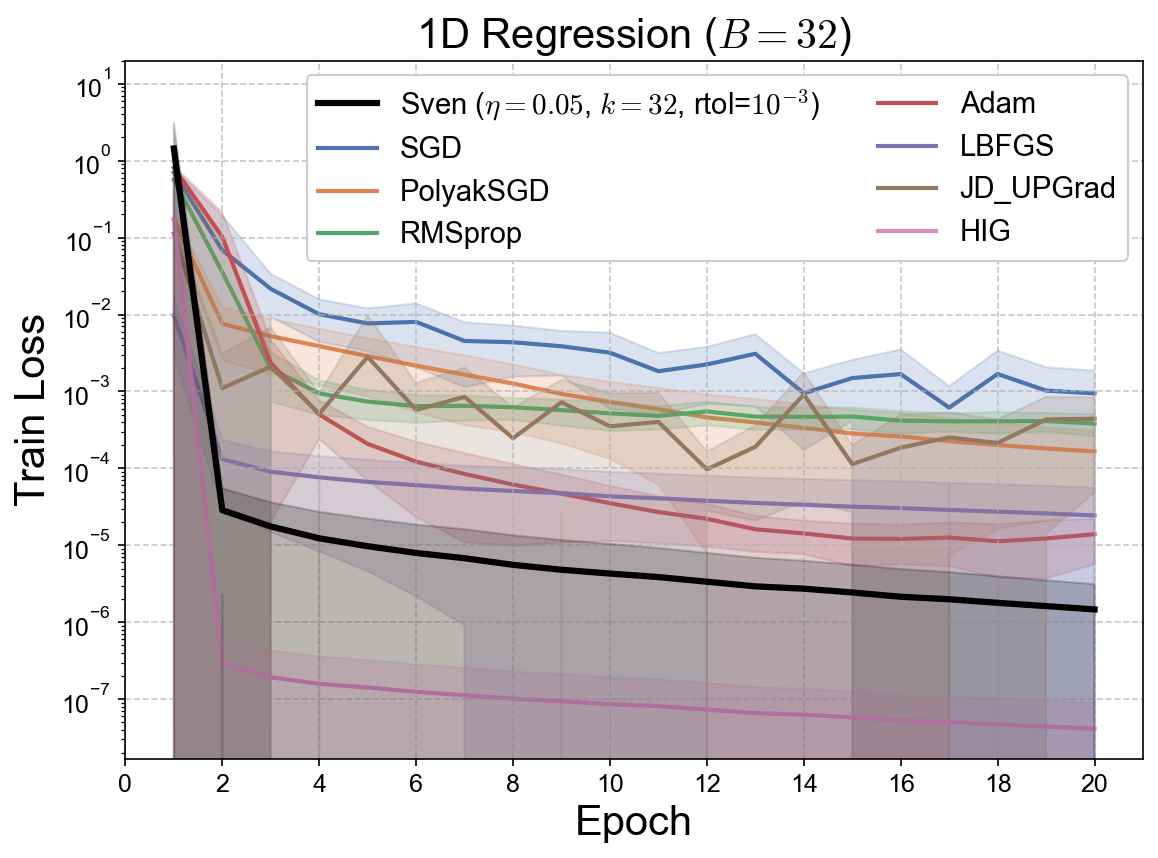

In [11]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))

# Best SVD
best_svd_df, svd_params = select_best_group(
    df_svd[df_svd['batch_size'] == bs], HYPERPARAM_COLS_SVD, optimizer='SVD'
)
mean, std = aggregate_curves(best_svd_df, 'train')
n_epochs = len(mean)
epochs_train = np.arange(1, n_epochs + 1)
svd_label = (f"Sven ($\eta={svd_params['lr']}$, "
             f"$k={int(svd_params['k'])}$, rtol=${lr_labels[svd_params['rtol']]}$)")
ax.plot(epochs_train, mean, color='k', linewidth=3, label=svd_label, zorder=2)
ax.fill_between(epochs_train, mean - std, mean + std, color='k', alpha=0.2, zorder=2)

# Best baselines
for i, opt in enumerate(BASELINE_OPT):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_df, _ = select_best_group(opt_df, HYPERPARAM_COLS[opt], optimizer=opt, n_seeds=n_seeds)
    mean, std = aggregate_curves(best_df, 'train')
    e = np.arange(1, len(mean) + 1)
    ax.plot(e, mean, color=colors[i], linewidth=2, label=opt, zorder=1)
    ax.fill_between(e, mean - std, mean + std, color=colors[i], alpha=0.2, zorder=1)

ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss')
ax.set_yscale('log')
plt.legend(ncol=2, loc='upper right', frameon=True, framealpha=1)
ax.set_title(f"1D Regression ($B = {bs}$)")
plt.ylim([None, 20])
plt.xlim(0, n_epochs + 1)
plt.xticks(np.arange(0, n_epochs + 1, max(1, n_epochs // 10)))
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'train_loss_best.pdf')
plt.show()

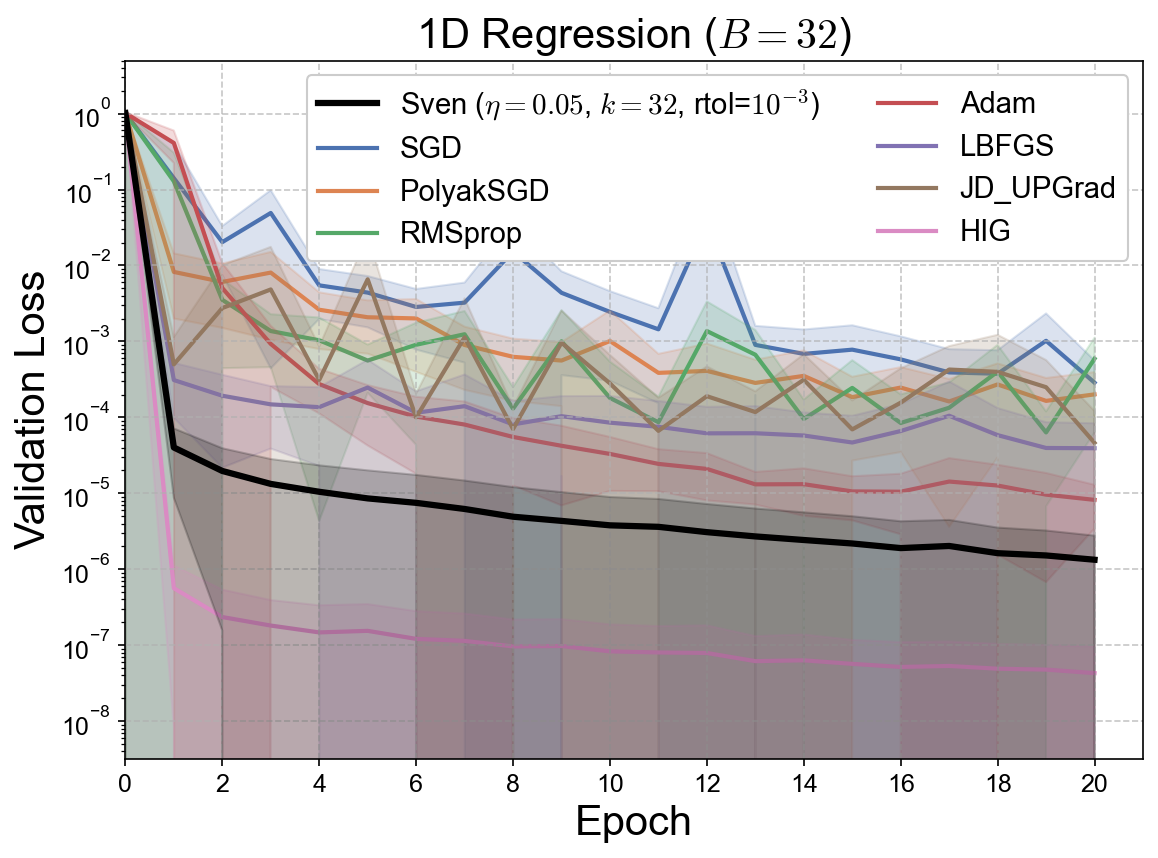

In [12]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))

# Best SVD
best_svd_df, svd_params = select_best_group(
    df_svd[df_svd['batch_size'] == bs], HYPERPARAM_COLS_SVD, optimizer='SVD'
)
mean, std = aggregate_curves(best_svd_df, 'val')
n_epochs = len(mean)
epochs_val = np.arange(0, n_epochs)
svd_label = (f"Sven ($\eta={svd_params['lr']}$, "
             f"$k={int(svd_params['k'])}$, rtol=${lr_labels[svd_params['rtol']]}$)")
ax.plot(epochs_val, mean, color='k', linewidth=3, label=svd_label, zorder=2)
ax.fill_between(epochs_val, mean - std, mean + std, color='k', alpha=0.2, zorder=2)

# Best baselines
for i, opt in enumerate(BASELINE_OPT):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_df, _ = select_best_group(opt_df, HYPERPARAM_COLS[opt], optimizer=opt, n_seeds=n_seeds)
    mean, std = aggregate_curves(best_df, 'val')
    e = np.arange(0, len(mean))
    ax.plot(e, mean, color=colors[i], linewidth=2, label=opt, zorder=1)
    ax.fill_between(e, mean - std, mean + std, color=colors[i], alpha=0.2, zorder=1)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
plt.legend(ncol=2, loc='upper right', frameon=True, framealpha=1)
ax.set_title(f"1D Regression ($B = {bs}$)")
plt.ylim([None, 5])
plt.xlim(0, n_epochs)
plt.xticks(np.arange(0, n_epochs + 1, max(1, n_epochs // 10)))
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'val_loss_best.pdf')
plt.show()

### Wall-time vs loss

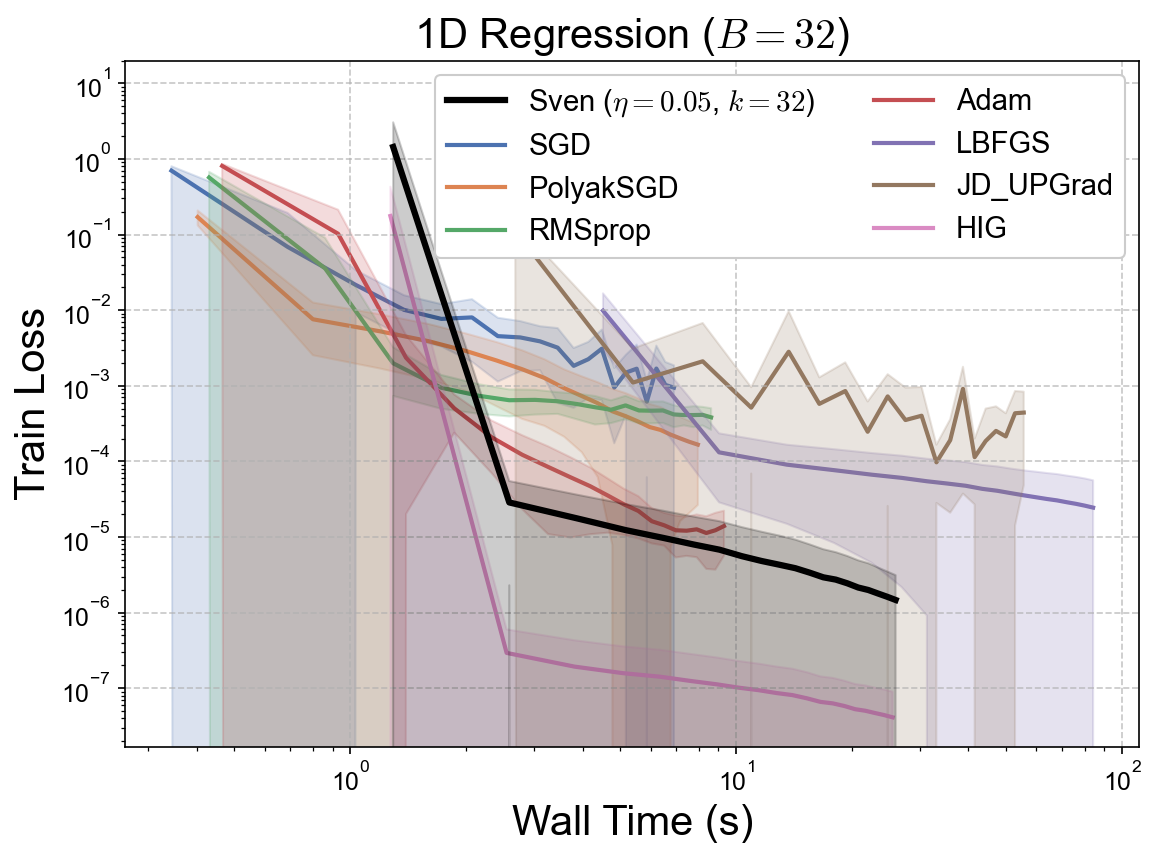

In [13]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))

# Best SVD
best_svd_df, svd_params = select_best_group(
    df_svd[df_svd['batch_size'] == bs], HYPERPARAM_COLS_SVD, optimizer='SVD'
)
mean, std = aggregate_curves(best_svd_df, 'train')
t = aggregate_cumulative_time(best_svd_df)
svd_label = (f"Sven ($\eta={svd_params['lr']}$, $k={int(svd_params['k'])}$)")
ax.plot(t, mean, color='k', linewidth=3, label=svd_label, zorder=2)
ax.fill_between(t, mean - std, mean + std, color='k', alpha=0.2, zorder=2)

# Best baselines
for i, opt in enumerate(BASELINE_OPT):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_df, _ = select_best_group(opt_df, HYPERPARAM_COLS[opt], optimizer=opt, n_seeds=n_seeds)
    mean, std = aggregate_curves(best_df, 'train')
    t = aggregate_cumulative_time(best_df)
    ax.plot(t, mean, color=colors[i], linewidth=2, label=opt, zorder=1)
    ax.fill_between(t, mean - std, mean + std, color=colors[i], alpha=0.2, zorder=1)

ax.set_xlabel('Wall Time (s)')
ax.set_ylabel('Train Loss')
ax.set_yscale('log')
plt.legend(ncol=2, loc='upper right', frameon=True, framealpha=1)
ax.set_title(f"1D Regression ($B = {bs}$)")
plt.ylim([None, 20])
plt.xscale('log')
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'wall_time_vs_train_loss_best.pdf')
plt.show()

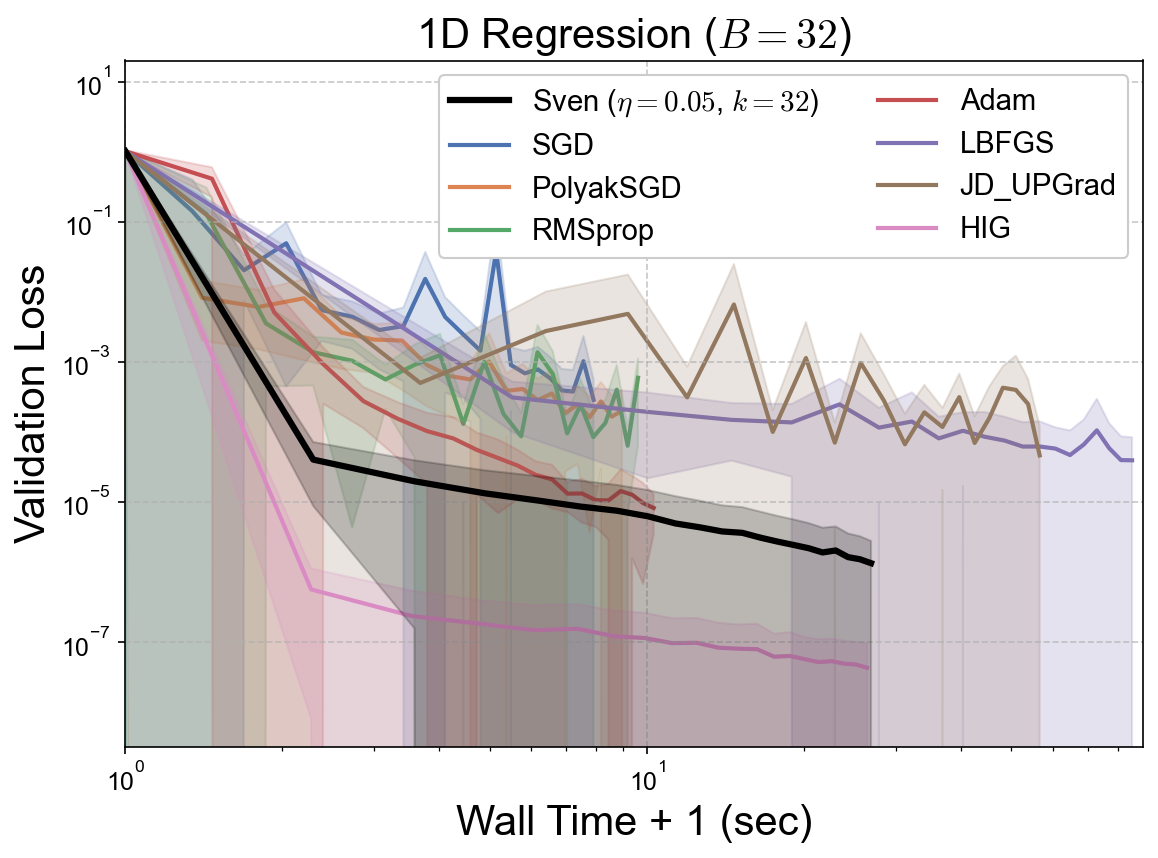

In [14]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))

# Best SVD
best_svd_df, svd_params = select_best_group(
    df_svd[df_svd['batch_size'] == bs], HYPERPARAM_COLS_SVD, optimizer='SVD'
)
mean, std = aggregate_curves(best_svd_df, 'val')
# Prepend 1s to align epoch 0 with t=1 (matches the original notebook).
t = aggregate_cumulative_time(best_svd_df, prepend=1)
svd_label = (f"Sven ($\eta={svd_params['lr']}$, $k={int(svd_params['k'])}$)")
ax.plot(t, mean, color='k', linewidth=3, label=svd_label, zorder=2)
ax.fill_between(t, mean - std, mean + std, color='k', alpha=0.2, zorder=2)

# Best baselines
for i, opt in enumerate(BASELINE_OPT):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_df, _ = select_best_group(opt_df, HYPERPARAM_COLS[opt], optimizer=opt, n_seeds=n_seeds)
    mean, std = aggregate_curves(best_df, 'val')
    t = aggregate_cumulative_time(best_df, prepend=1)
    ax.plot(t, mean, color=colors[i], linewidth=2, label=opt, zorder=1)
    ax.fill_between(t, mean - std, mean + std, color=colors[i], alpha=0.2, zorder=1)

ax.set_xlabel('Wall Time + 1 (sec)')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
plt.legend(ncol=2, loc='upper right', frameon=True, framealpha=1)
ax.set_title(f"1D Regression ($B = {bs}$)")
plt.ylim([None, 20])
plt.xlim([1, None])
plt.xscale('log')
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'wall_time_vs_val_loss_best.pdf')
plt.show()

### overlay different $k$ values (mean over seeds, $\pm 1\sigma$ band)

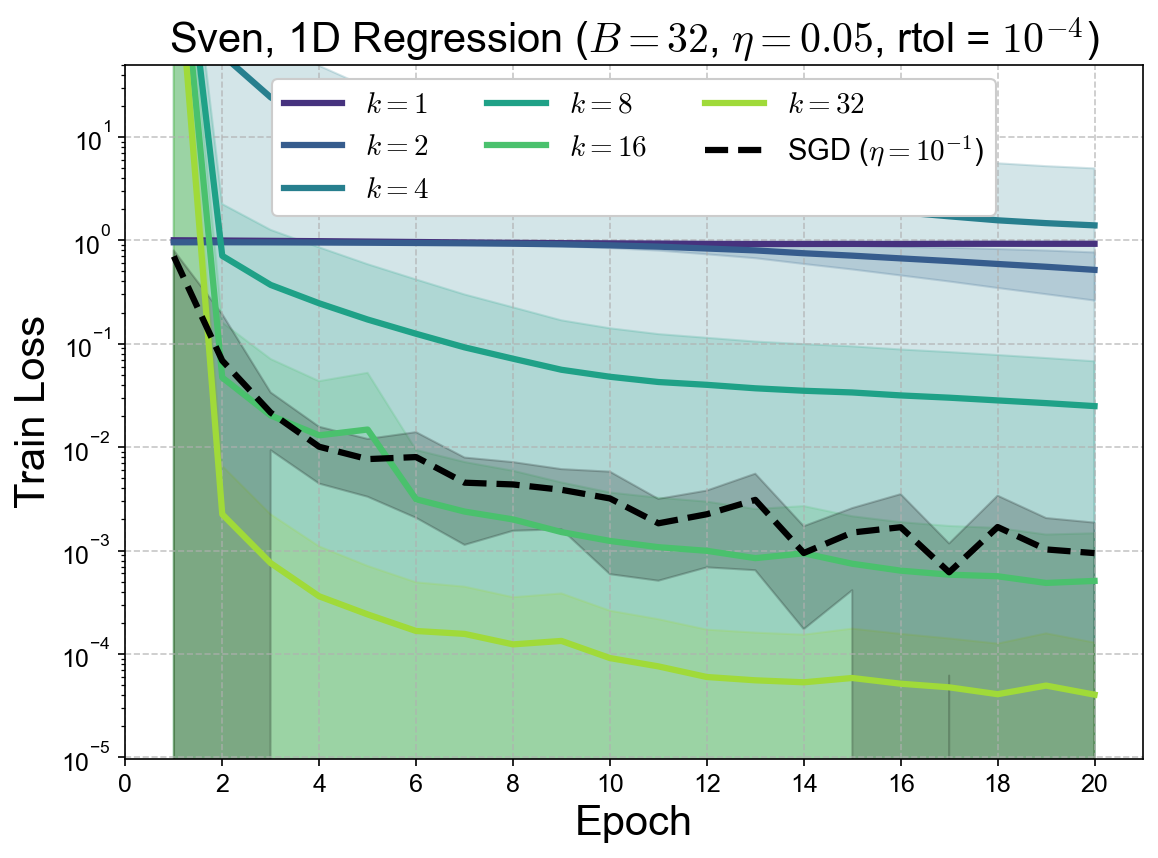

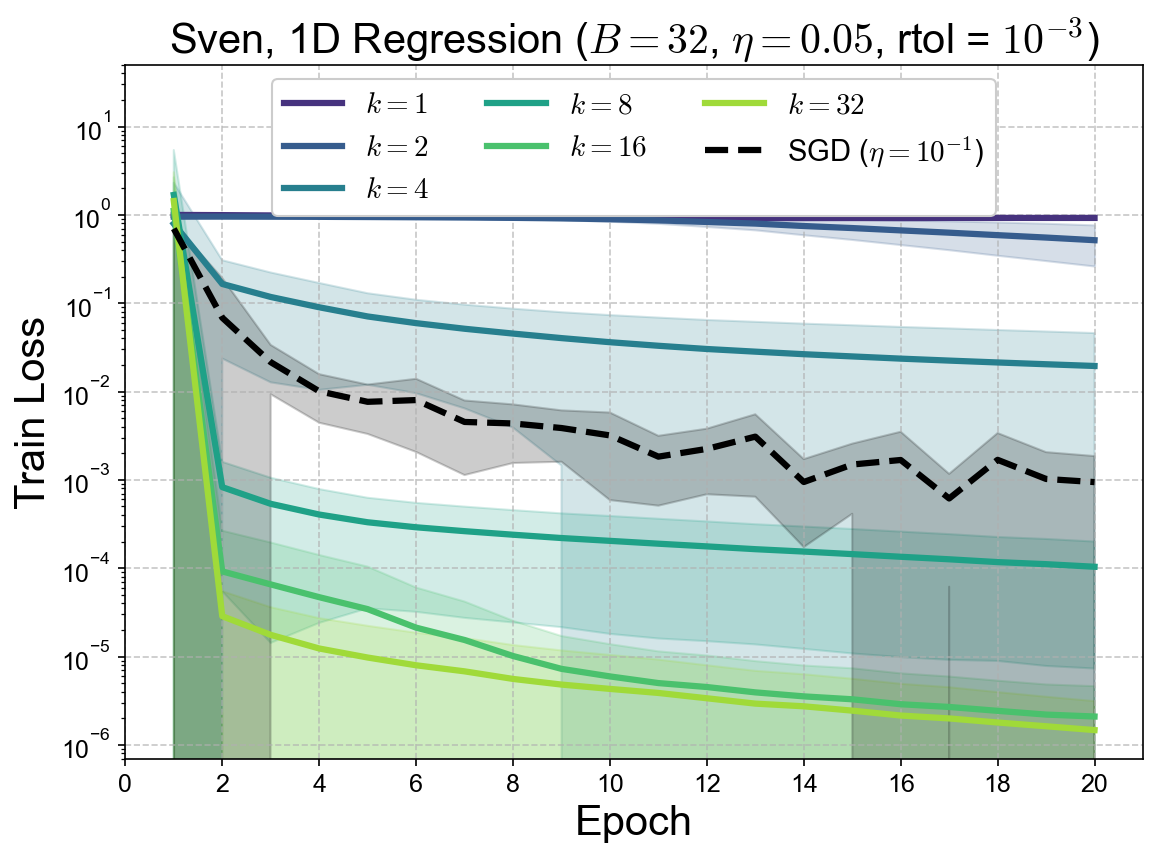

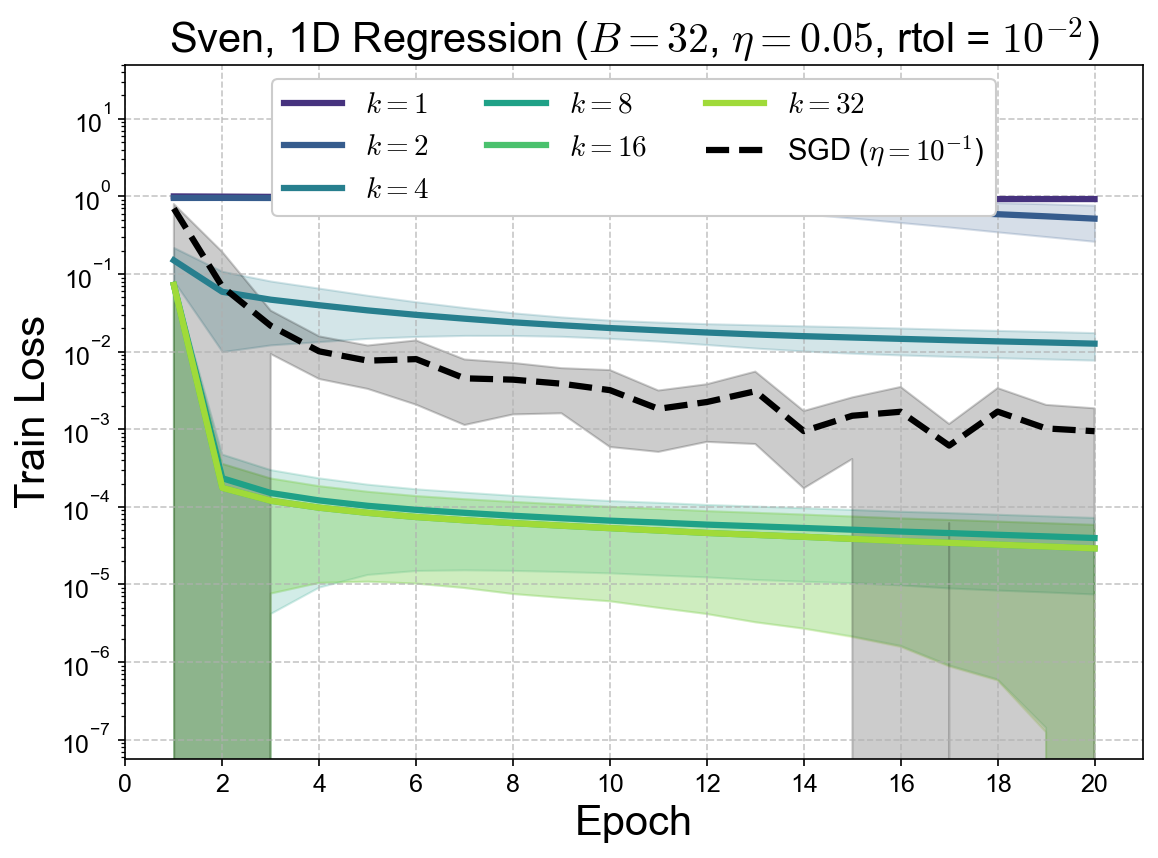

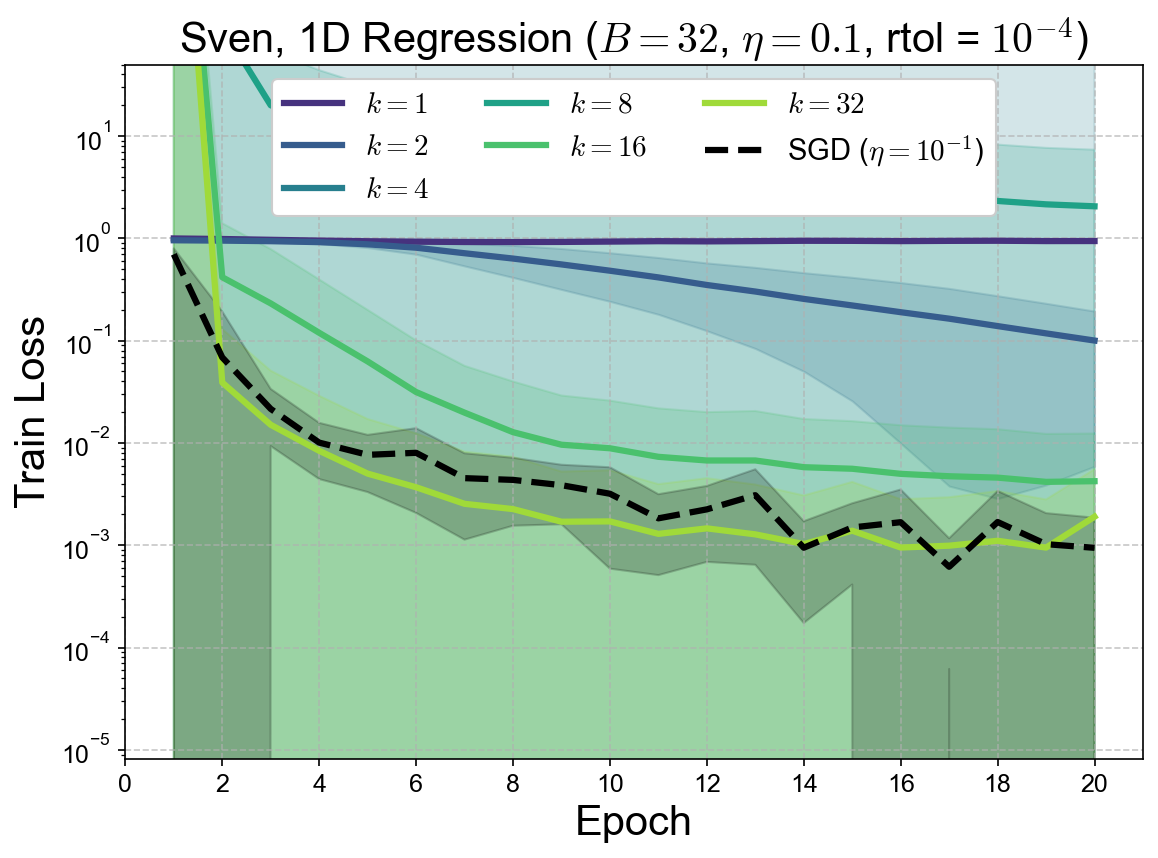

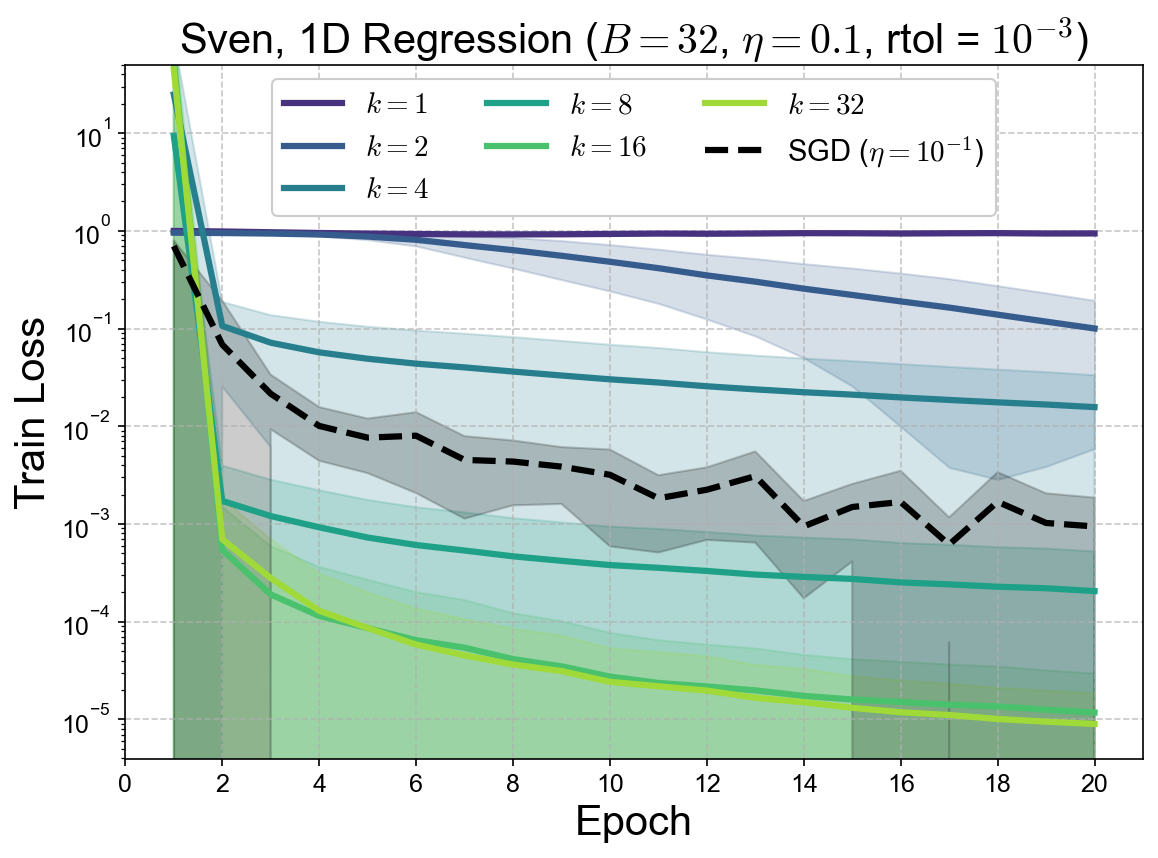

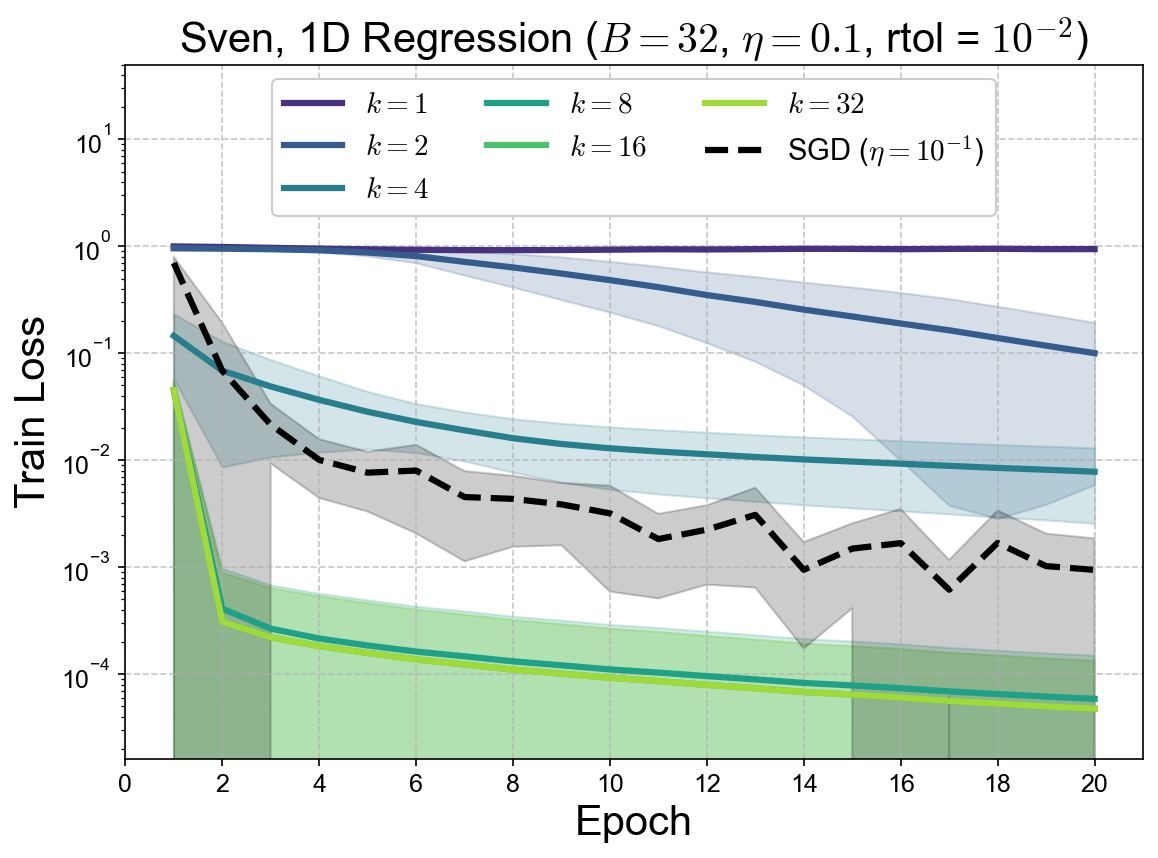

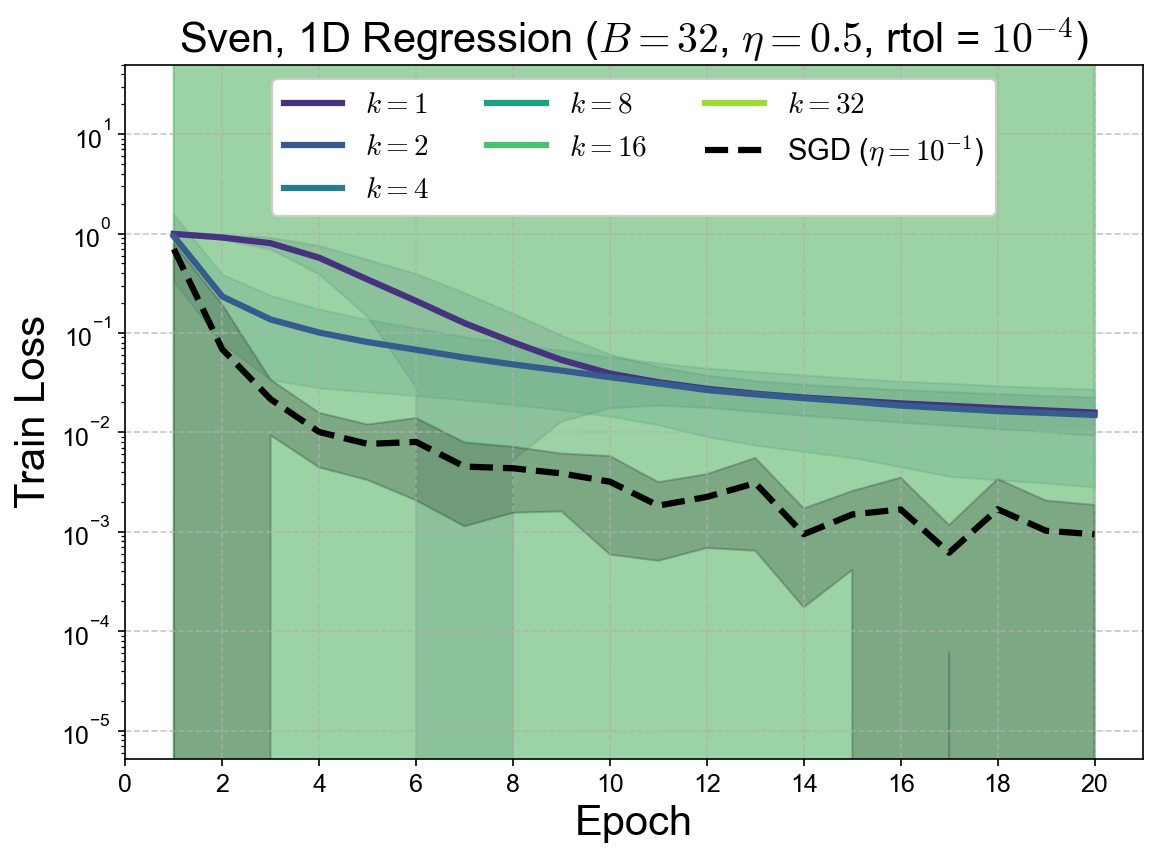

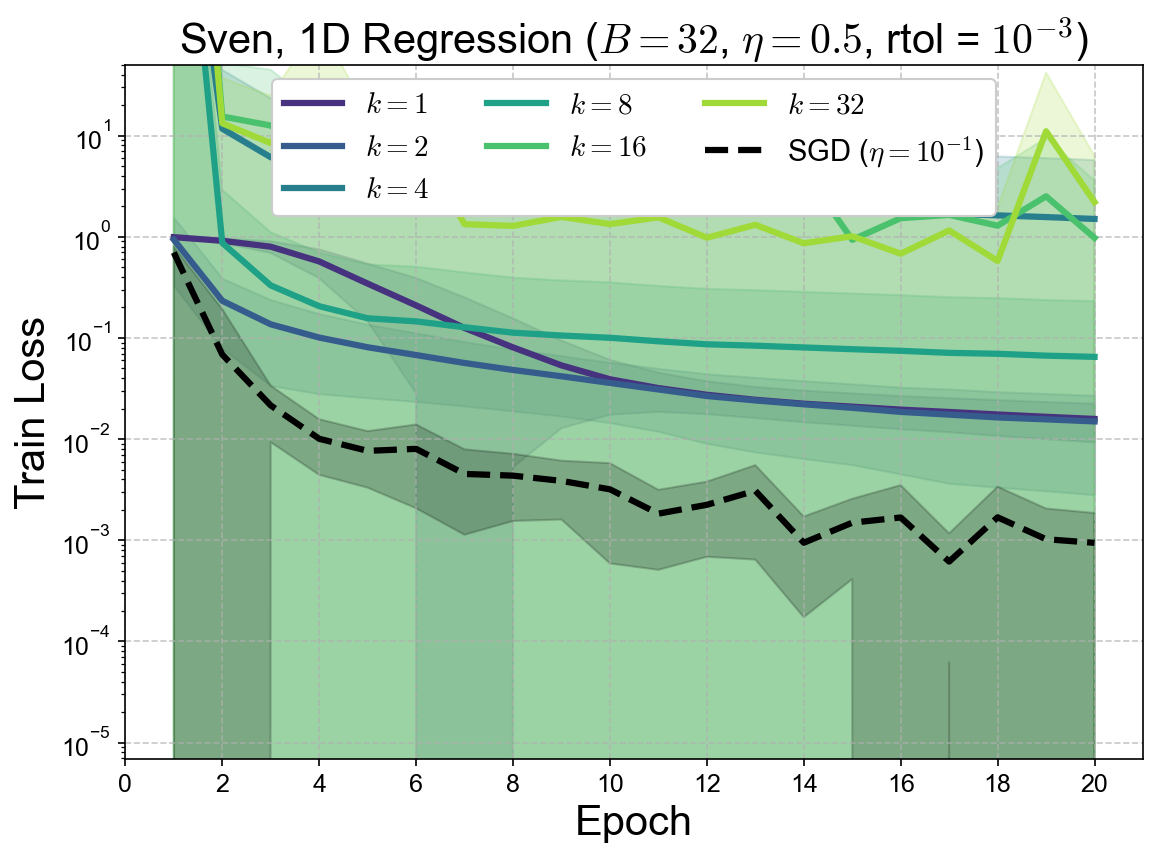

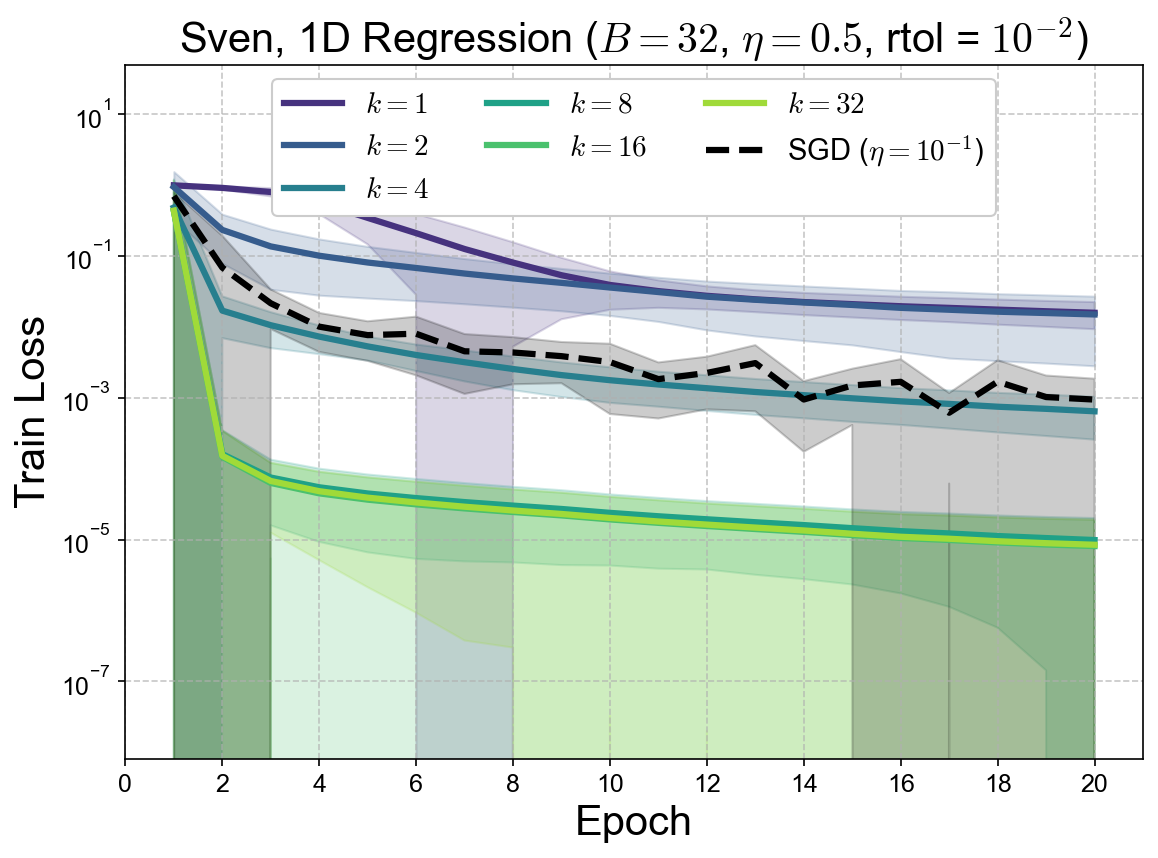

In [15]:
for LR in [0.05, 0.1, 0.5]:
    for RTOL in [0.0001, 0.001, 0.01]:
        fig, ax = plt.subplots(figsize=(8, 6))
        df_sel = df_svd[(df_svd['batch_size'] == bs) & (df_svd['lr'] == LR) & (df_svd['rtol'] == RTOL)]
        if len(df_sel) == 0:
            plt.close(fig)
            continue
        k_values = sorted(df_sel['k'].unique())
        kcolors = sns.color_palette("viridis", n_colors=len(k_values))
        n_epochs = 0
        for i, k in enumerate(k_values):
            group = df_sel[df_sel['k'] == k]
            mean, std = aggregate_curves(group, 'train')
            n_epochs = max(n_epochs, len(mean))
            epochs = np.arange(1, len(mean) + 1)
            ax.plot(epochs, mean, label=f"$k={int(k)}$", color=kcolors[i], linewidth=3)
            ax.fill_between(epochs, mean - std, mean + std, color=kcolors[i], alpha=0.2)

        df_sgd = df_baseline[(df_baseline['batch_size'] == bs) & (df_baseline['optimizer'] == 'SGD')]
        best_sgd_df, sgd_params = select_best_group(df_sgd, HYPERPARAM_COLS['SGD'], optimizer='SGD', n_seeds=n_seeds)
        mean, std = aggregate_curves(best_sgd_df, 'train')
        epochs = np.arange(1, len(mean) + 1)
        ax.plot(epochs, mean, label=f"SGD ($\eta={lr_labels[sgd_params['lr']]}$)",
                color='k', linestyle='--', linewidth=3)
        ax.fill_between(epochs, mean - std, mean + std, color='k', alpha=0.2)

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Train Loss')
        ax.set_yscale('log')
        plt.legend(ncol=3, loc='upper center', frameon=True, framealpha=1)
        ax.set_title(f"Sven, 1D Regression ($B = {bs}$, $\eta={LR}$, rtol = ${lr_labels[RTOL]}$)")
        plt.ylim([None, 50])
        plt.xlim(0, n_epochs + 1)
        plt.xticks(np.arange(0, n_epochs + 1, max(1, n_epochs // 10)))
        plt.grid(axis='both', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f"train_loss_k_comparison_bs{bs}_lr{LR}_rtol{RTOL}.pdf")
        plt.show()

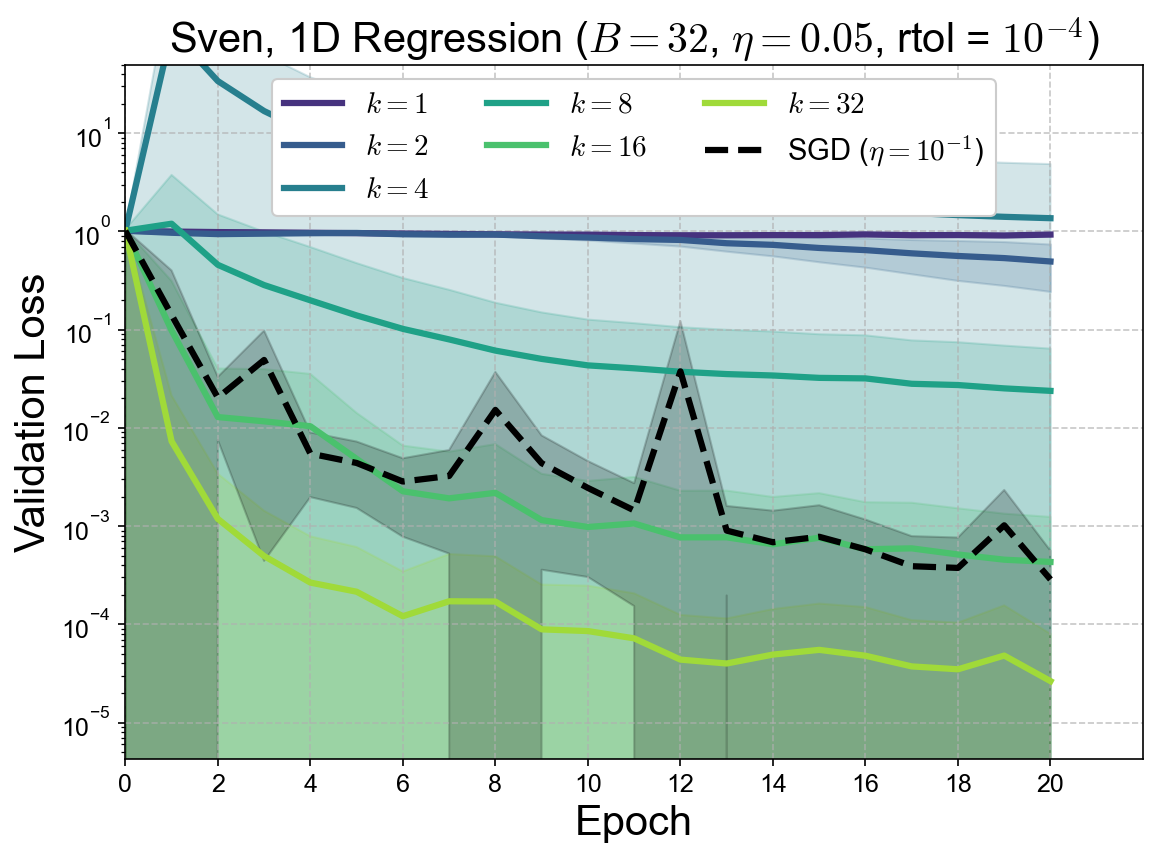

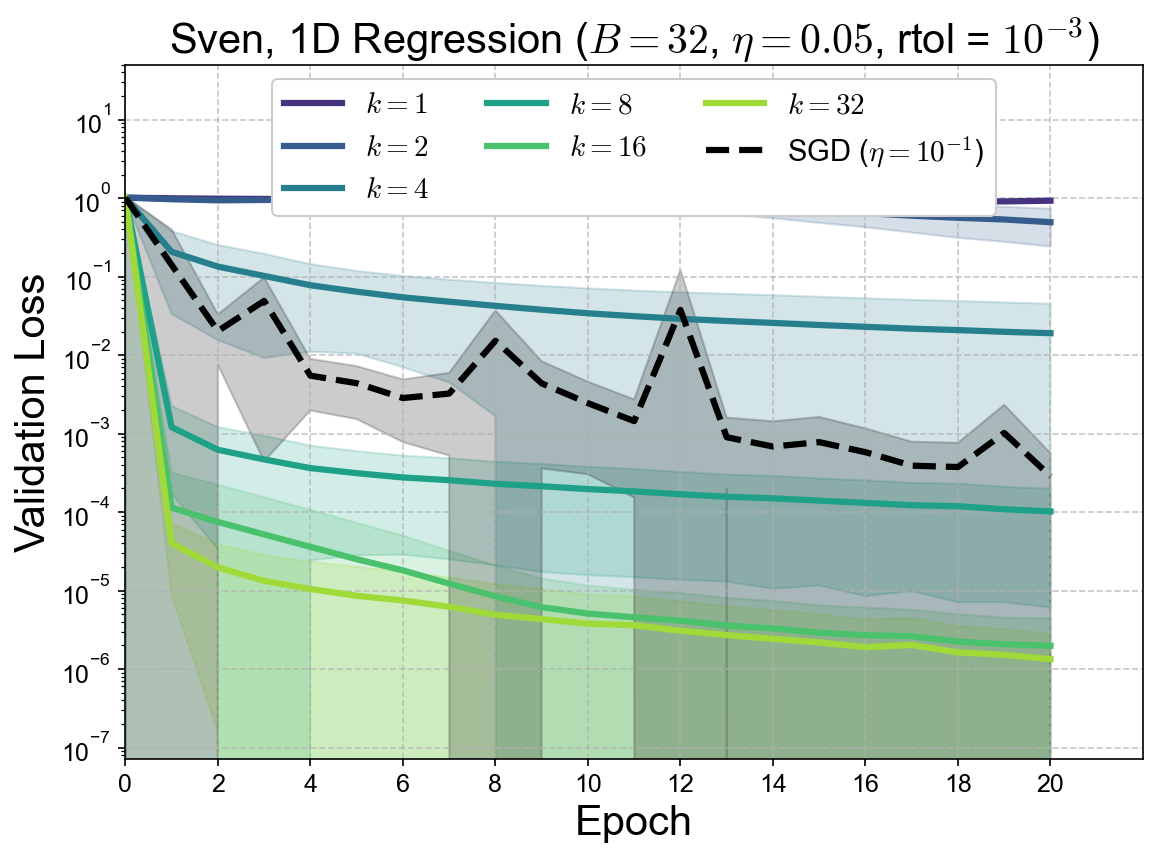

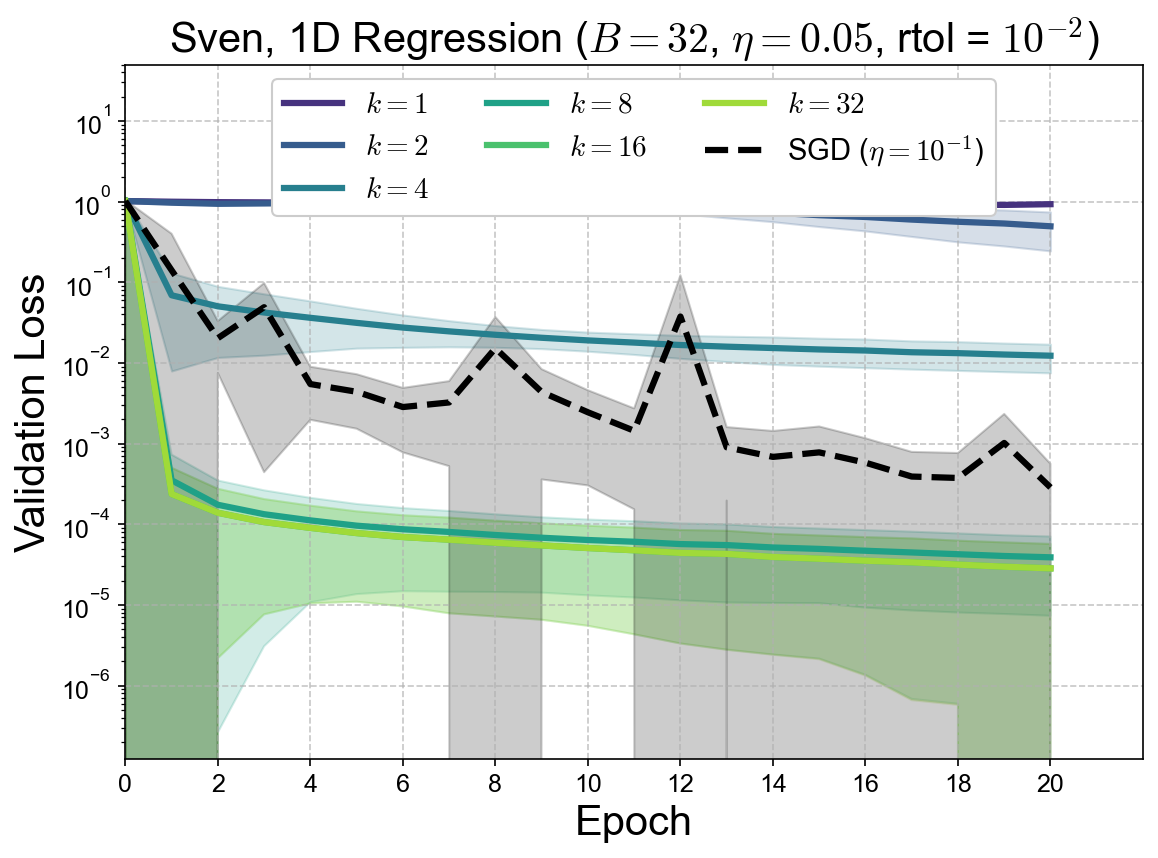

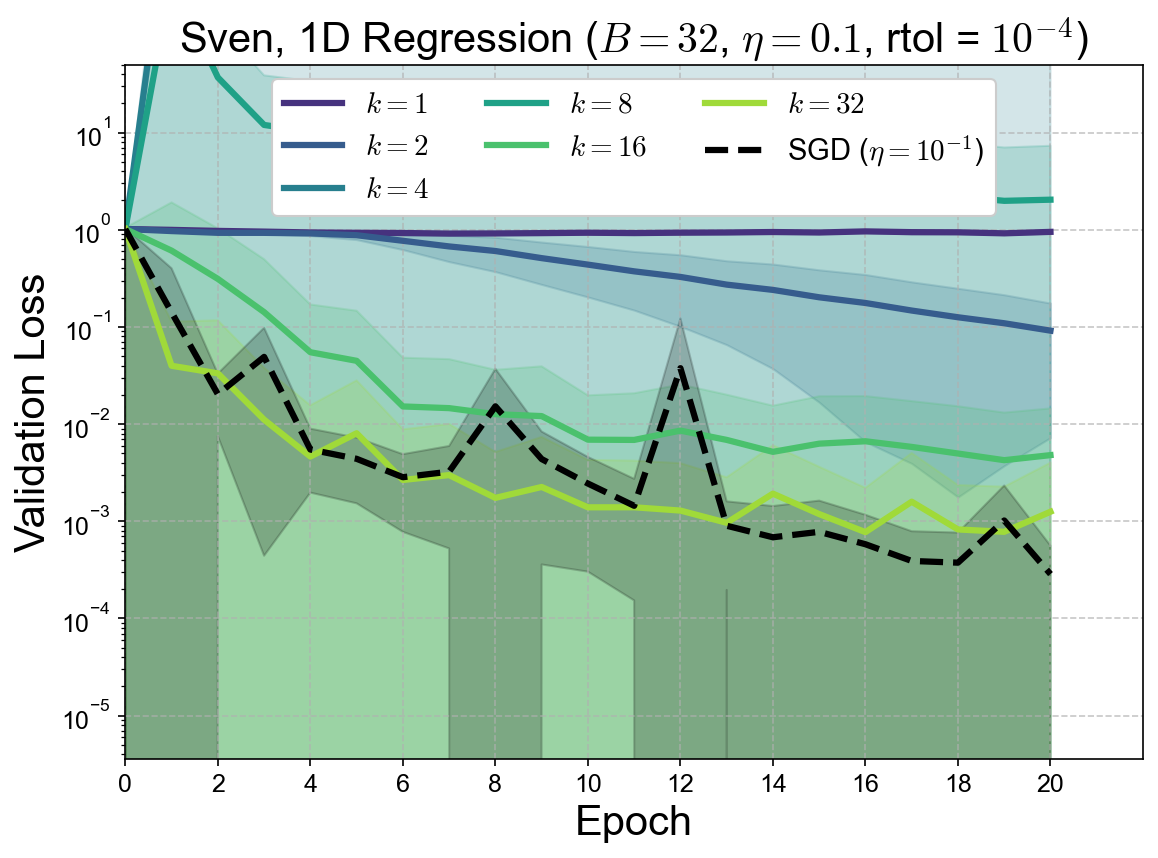

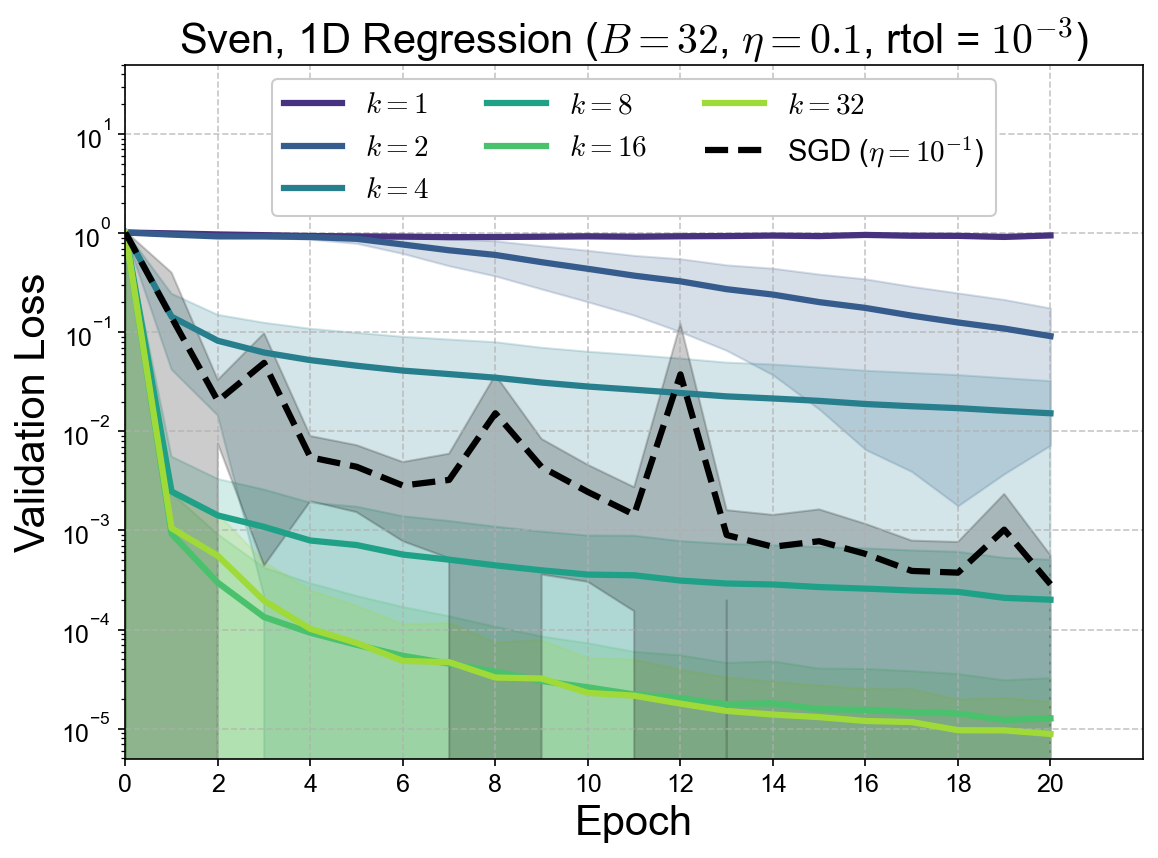

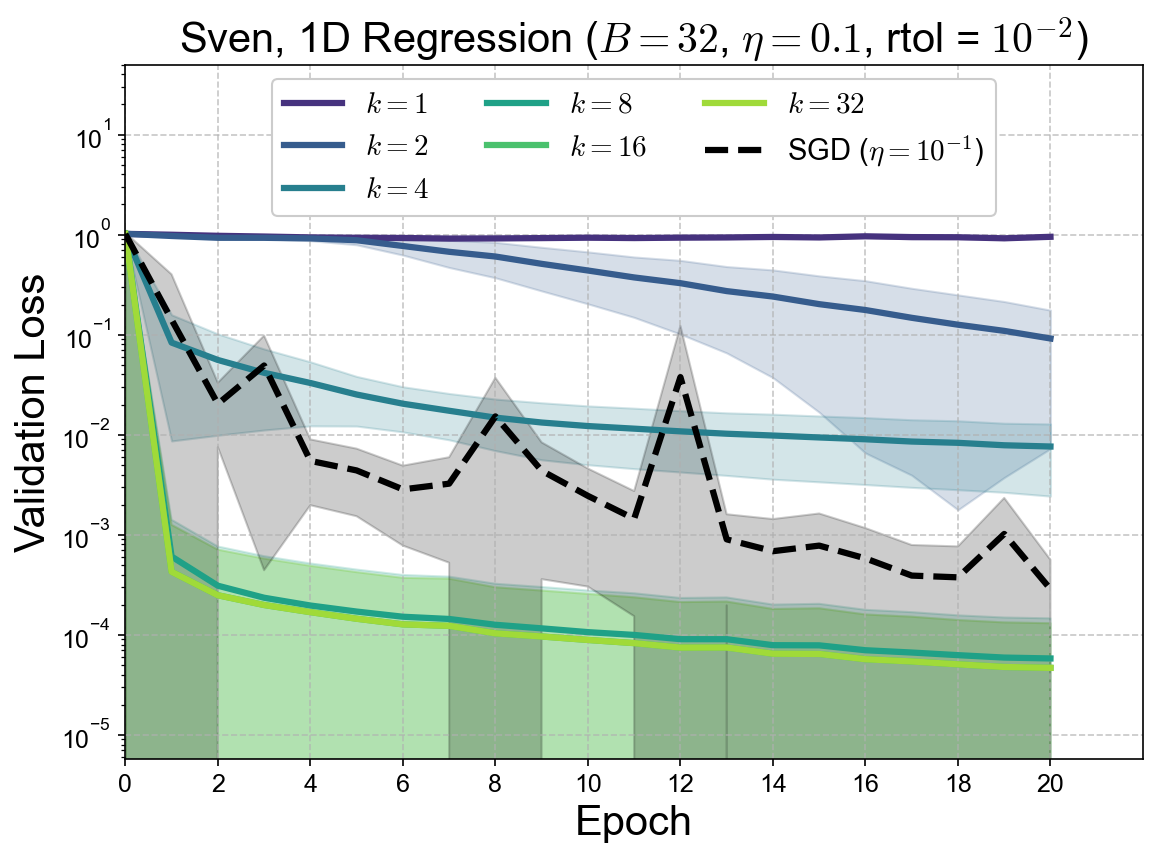

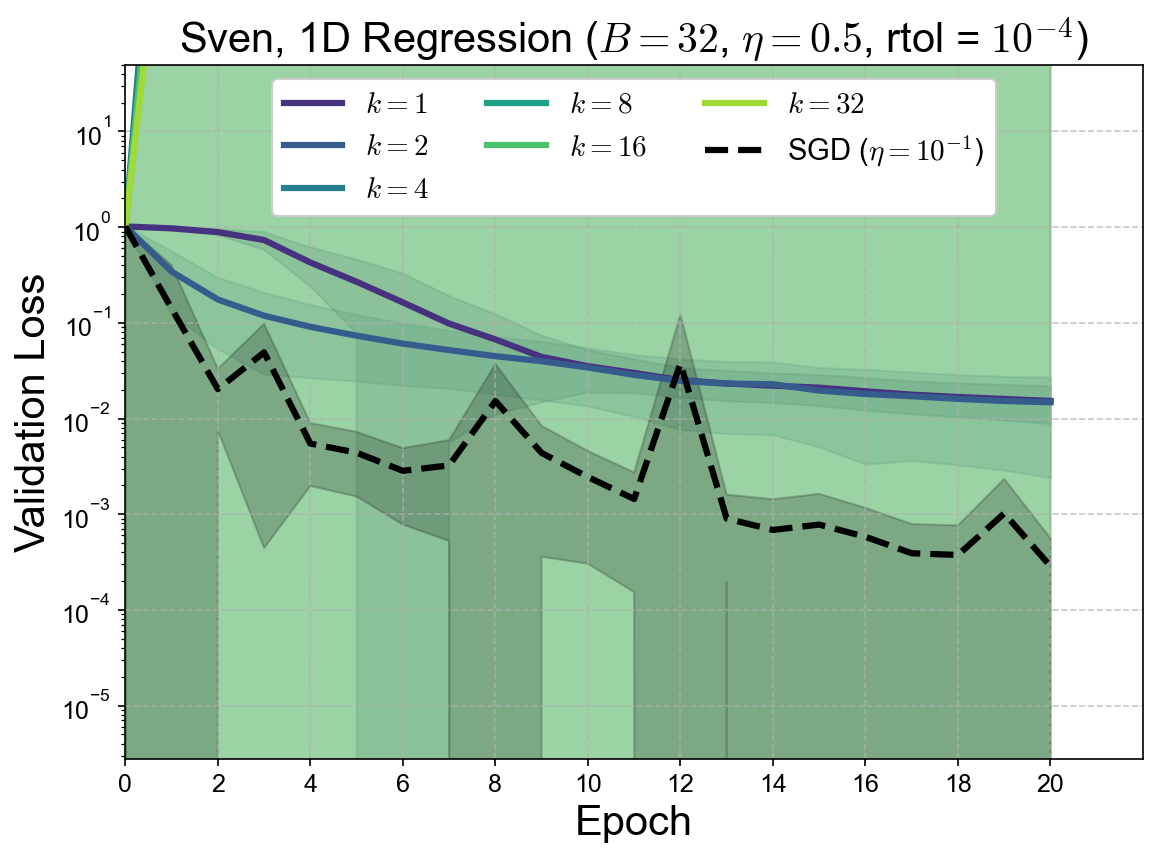

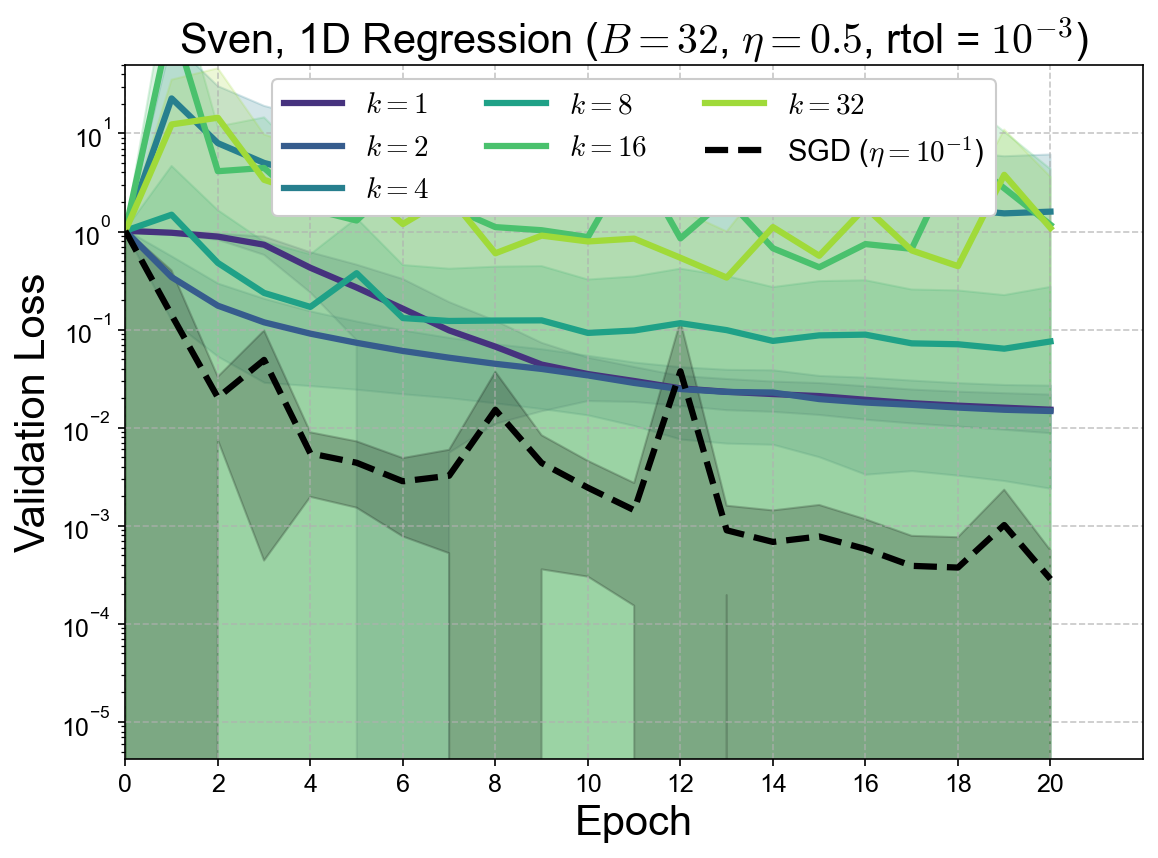

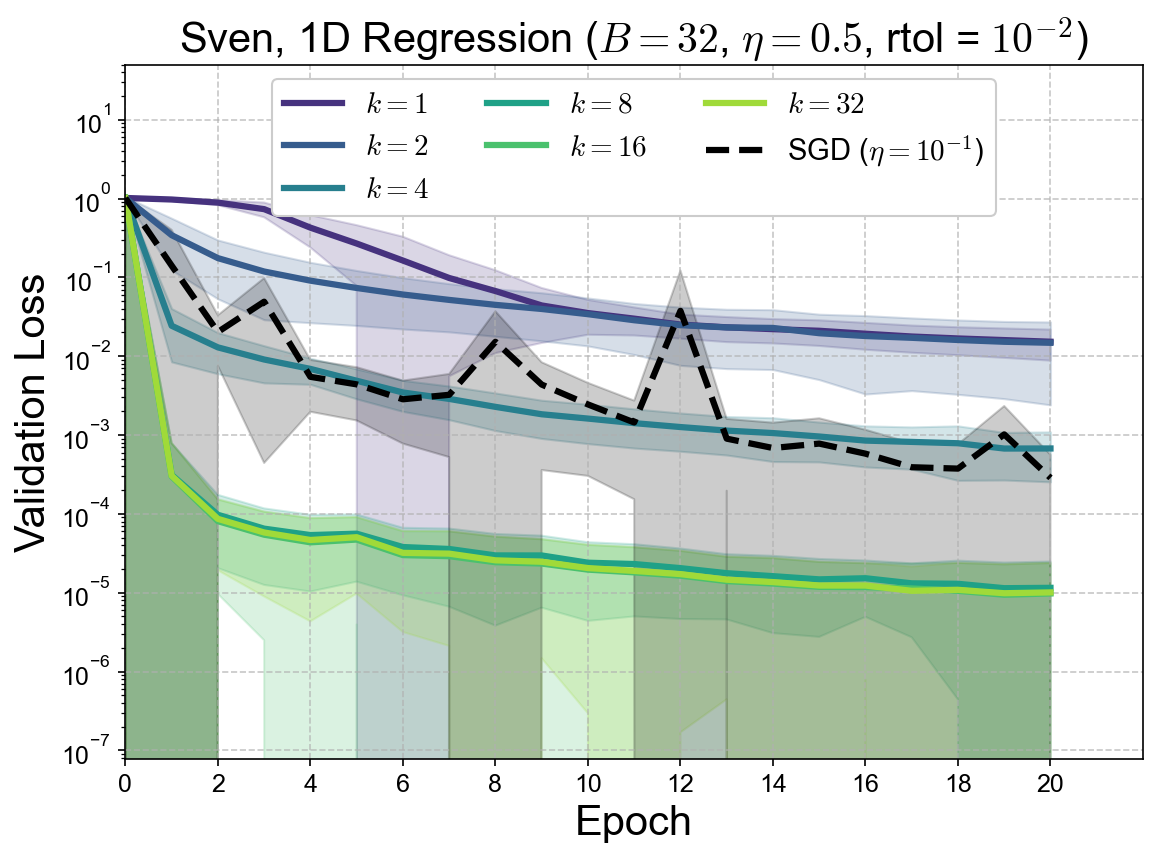

In [16]:
for LR in [0.05, 0.1, 0.5]:
    for RTOL in [0.0001, 0.001, 0.01]:
        fig, ax = plt.subplots(figsize=(8, 6))
        df_sel = df_svd[(df_svd['batch_size'] == bs) & (df_svd['lr'] == LR) & (df_svd['rtol'] == RTOL)]
        if len(df_sel) == 0:
            plt.close(fig)
            continue
        k_values = sorted(df_sel['k'].unique())
        kcolors = sns.color_palette("viridis", n_colors=len(k_values))
        n_epochs = 0
        for i, k in enumerate(k_values):
            group = df_sel[df_sel['k'] == k]
            mean, std = aggregate_curves(group, 'val')
            n_epochs = max(n_epochs, len(mean))
            epochs = np.arange(0, len(mean))
            ax.plot(epochs, mean, label=f"$k={int(k)}$", color=kcolors[i], linewidth=3)
            ax.fill_between(epochs, mean - std, mean + std, color=kcolors[i], alpha=0.2)

        df_sgd = df_baseline[(df_baseline['batch_size'] == bs) & (df_baseline['optimizer'] == 'SGD')]
        best_sgd_df, sgd_params = select_best_group(df_sgd, HYPERPARAM_COLS['SGD'], optimizer='SGD', n_seeds=n_seeds)
        mean, std = aggregate_curves(best_sgd_df, 'val')
        epochs = np.arange(0, len(mean))
        ax.plot(epochs, mean, label=f"SGD ($\eta={lr_labels[sgd_params['lr']]}$)",
                color='k', linestyle='--', linewidth=3)
        ax.fill_between(epochs, mean - std, mean + std, color='k', alpha=0.2)

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Validation Loss')
        ax.set_yscale('log')
        plt.legend(ncol=3, loc='upper center', frameon=True, framealpha=1)
        ax.set_title(f"Sven, 1D Regression ($B = {bs}$, $\eta={LR}$, rtol = ${lr_labels[RTOL]}$)")
        plt.ylim([None, 50])
        plt.xlim(0, n_epochs + 1)
        plt.xticks(np.arange(0, n_epochs + 1, max(1, n_epochs // 10)))
        plt.grid(axis='both', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f"val_loss_k_comparison_bs{bs}_lr{LR}_rtol{RTOL}.pdf")
        plt.show()